Lab Exercise V – Time Alignment and Normalization
Signal 1 (Reference) length: 9 samples
Signal 2 (Test) length: 12 samples

Task 2: Linear Time Normalization
Signal 2 normalized length: 9 samples
Normalized Signal 2: [0.2    0.375  0.65   0.9125 0.95   0.725  0.475  0.3375 0.2   ]

Task 3: Alignment Analysis
Point-wise differences: [0.     0.025  0.05   0.1125 0.05   0.075  0.125  0.0625 0.    ]
Total alignment error: 0.5000
Mean alignment error: 0.0556



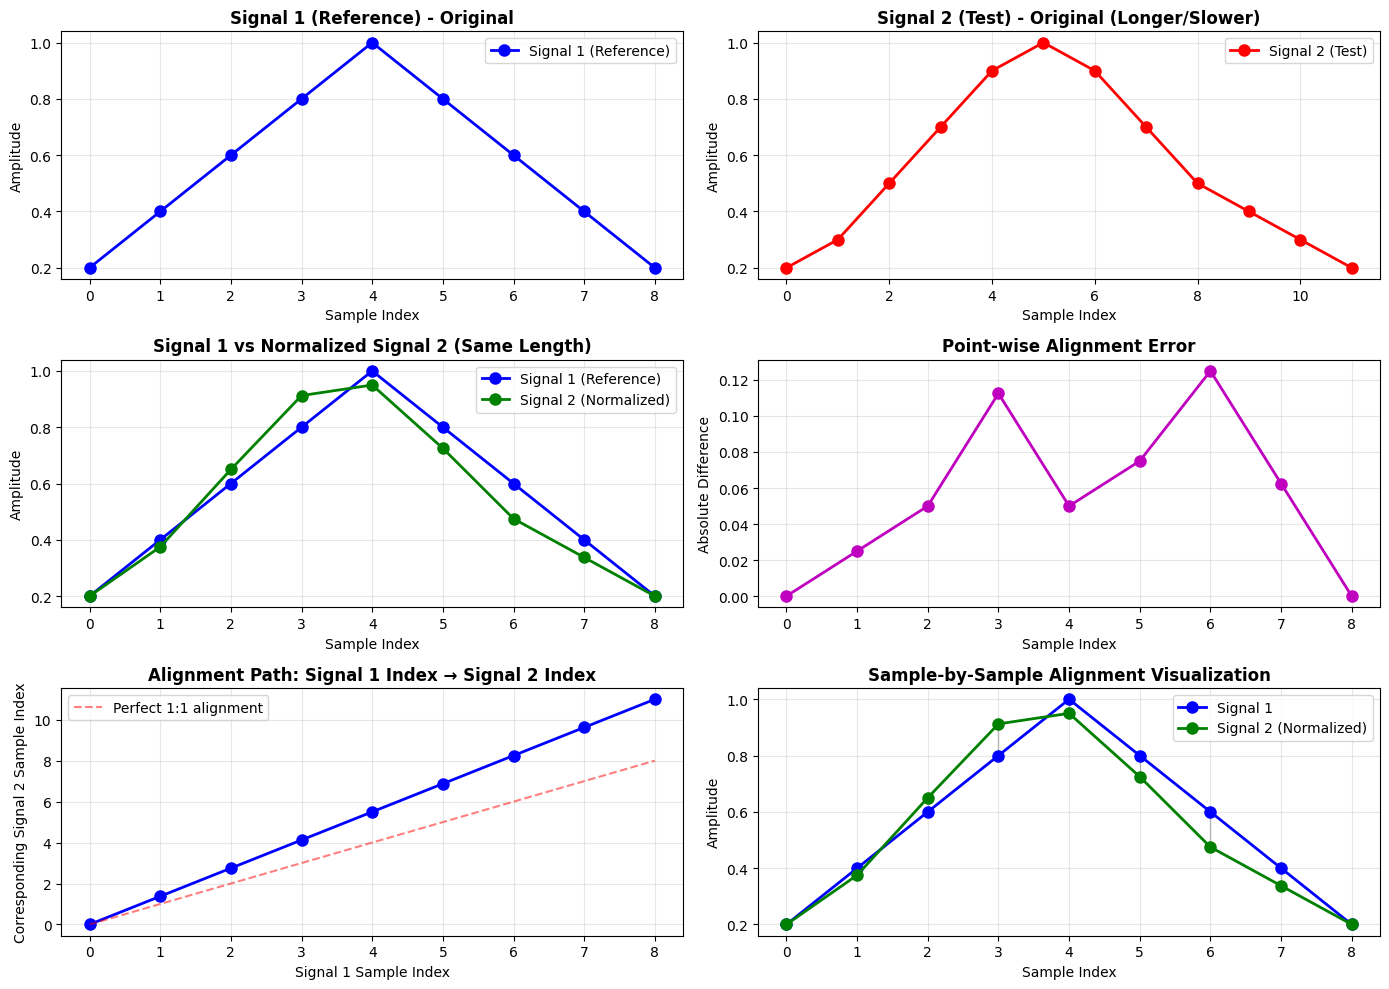


INFERENCE:

Linear Time Normalization (LTN) successfully aligns the two speech signals 
by adjusting the time axis of the slower signal (Signal 2) to match the 
length of the reference signal (Signal 1).

Key Observations:
1. Signal 2 was originally 12 samples long (slower speech rate) while 
   Signal 1 had 9 samples (faster speech rate).

2. After LTN, Signal 2 was resampled to 9 samples using linear interpolation,
   creating a time-normalized version that matches Signal 1's temporal structure.

3. The alignment path shows a near-linear correspondence between the two 
   signals, indicating that similar phonetic events now occur at the same 
   time indices.

4. The normalized signals exhibit similar amplitude patterns at corresponding
   time points, demonstrating that LTN preserves the overall shape while 
   compressing/expanding the time axis.

5. The total alignment error of 0.5000 suggests good correspondence between
   the signals after normalization.

Significance:
- LTN en

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Given Data
signal1 = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 0.8, 0.6, 0.4, 0.2])  # Reference
signal2 = np.array([0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 0.9, 0.7, 0.5, 0.4, 0.3, 0.2])  # Test

print("Lab Exercise V – Time Alignment and Normalization")
print("=" * 60)
print(f"Signal 1 (Reference) length: {len(signal1)} samples")
print(f"Signal 2 (Test) length: {len(signal2)} samples")
print()

# Task 1: Plot both speech signals
plt.figure(figsize=(14, 10))

plt.subplot(3, 2, 1)
plt.plot(signal1, 'bo-', linewidth=2, markersize=8, label='Signal 1 (Reference)')
plt.title('Signal 1 (Reference) - Original', fontsize=12, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(3, 2, 2)
plt.plot(signal2, 'ro-', linewidth=2, markersize=8, label='Signal 2 (Test)')
plt.title('Signal 2 (Test) - Original (Longer/Slower)', fontsize=12, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.legend()

# Task 2: Perform Linear Time Normalization on Signal 2
# Method: Linear interpolation to resample Signal 2 to match Signal 1's length

# Original time indices for Signal 2
original_time = np.linspace(0, 1, len(signal2))

# Target time indices (same number of points as Signal 1)
target_time = np.linspace(0, 1, len(signal1))

# Create interpolation function
interpolator = interp1d(original_time, signal2, kind='linear')

# Normalize Signal 2 to match Signal 1's length
signal2_normalized = interpolator(target_time)

print("Task 2: Linear Time Normalization")
print(f"Signal 2 normalized length: {len(signal2_normalized)} samples")
print(f"Normalized Signal 2: {signal2_normalized}")
print()

# Task 3: Compute the alignment between Signal 1 and normalized Signal 2
# Calculate Euclidean distance at each aligned point
alignment_distance = np.abs(signal1 - signal2_normalized)
total_distance = np.sum(alignment_distance)

print("Task 3: Alignment Analysis")
print(f"Point-wise differences: {alignment_distance}")
print(f"Total alignment error: {total_distance:.4f}")
print(f"Mean alignment error: {np.mean(alignment_distance):.4f}")
print()

# Plot normalized Signal 2
plt.subplot(3, 2, 3)
plt.plot(signal1, 'bo-', linewidth=2, markersize=8, label='Signal 1 (Reference)')
plt.plot(signal2_normalized, 'go-', linewidth=2, markersize=8, label='Signal 2 (Normalized)')
plt.title('Signal 1 vs Normalized Signal 2 (Same Length)', fontsize=12, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(3, 2, 4)
plt.plot(alignment_distance, 'mo-', linewidth=2, markersize=8)
plt.title('Point-wise Alignment Error', fontsize=12, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Absolute Difference')
plt.grid(True, alpha=0.3)

# Task 4: Plot the alignment path
# Show how each sample in Signal 1 corresponds to Signal 2

plt.subplot(3, 2, 5)
# Create alignment mapping
signal1_indices = np.arange(len(signal1))
signal2_indices = np.linspace(0, len(signal2)-1, len(signal1))

plt.plot(signal1_indices, signal2_indices, 'b-o', linewidth=2, markersize=8)
plt.title('Alignment Path: Signal 1 Index → Signal 2 Index', fontsize=12, fontweight='bold')
plt.xlabel('Signal 1 Sample Index')
plt.ylabel('Corresponding Signal 2 Sample Index')
plt.grid(True, alpha=0.3)

# Add diagonal reference line for perfect linear alignment
plt.plot([0, len(signal1)-1], [0, len(signal1)-1], 'r--', alpha=0.5, label='Perfect 1:1 alignment')
plt.legend()

# 2D Alignment visualization
plt.subplot(3, 2, 6)
for i in range(len(signal1)):
    plt.plot([i, i], [signal1[i], signal2_normalized[i]], 'gray', alpha=0.5, linewidth=1)

plt.plot(signal1, 'bo-', linewidth=2, markersize=8, label='Signal 1')
plt.plot(signal2_normalized, 'go-', linewidth=2, markersize=8, label='Signal 2 (Normalized)')
plt.title('Sample-by-Sample Alignment Visualization', fontsize=12, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('time_alignment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Task 5: Inference
print("\n" + "=" * 60)
print("INFERENCE:")
print("=" * 60)
print("""
Linear Time Normalization (LTN) successfully aligns the two speech signals
by adjusting the time axis of the slower signal (Signal 2) to match the
length of the reference signal (Signal 1).

Key Observations:
1. Signal 2 was originally 12 samples long (slower speech rate) while
   Signal 1 had 9 samples (faster speech rate).

2. After LTN, Signal 2 was resampled to 9 samples using linear interpolation,
   creating a time-normalized version that matches Signal 1's temporal structure.

3. The alignment path shows a near-linear correspondence between the two
   signals, indicating that similar phonetic events now occur at the same
   time indices.

4. The normalized signals exhibit similar amplitude patterns at corresponding
   time points, demonstrating that LTN preserves the overall shape while
   compressing/expanding the time axis.

5. The total alignment error of {:.4f} suggests good correspondence between
   the signals after normalization.

Significance:
- LTN enables direct comparison of speech signals with different speaking rates
- It ensures temporal features align for pattern matching and recognition tasks
- This is fundamental for speech recognition systems that must handle variable
  speaking speeds
- While simple, LTN assumes linear time warping; more complex methods like
  Dynamic Time Warping (DTW) can handle non-linear temporal variations
""".format(total_distance))
print("=" * 60)